In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("../data/novagen_dataset.csv")

In [3]:
# ── Fix boolean columns ────────────────────────────────
# These two columns were stored as "True"/"False" strings
# .map() replaces each value using the dictionary lookup
# We handle both string version AND actual bool version
# because pandas can read CSVs differently based on version

bool_cols = ["Diet_Type__Vegan", "Diet_Type__Vegetarian"]
for col in bool_cols:
    df[col] = df[col].map({
        "True": 1,
        "False": 0,
        True: 1,
        False: 0
    })

In [4]:
# ── Separate features and target ───────────────────────
# X = everything the model LEARNS from (inputs)
# y = what the model PREDICTS (output)
# axis=1 means drop a column (axis=0 would drop a row)

X = df.drop("Target", axis=1)
y = df["Target"]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target Values:\n{y.unique()}")

Features (X) shape: (9549, 22)
Target (y) shape: (9549,)
Target Values:
[1 0]


# Train-Test Split

In [6]:
# ── Train-test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTrain Target Distribution: \n{y_train.value_counts()}")
print(f"\nTest Target Distribution: \n{y_test.value_counts()}")


Training samples: 7639
Test samples: 1910

Train Target Distribution: 
Target
1    3983
0    3656
Name: count, dtype: int64

Test Target Distribution: 
Target
1    996
0    914
Name: count, dtype: int64


# Feature Scaling

In [7]:
# ── Standard Scaling ───────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print(f"Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}" )
print(f"Std of first feature (train): {X_train_scaled[:, 0].std():.4f}" )

Scaling done
Mean of first feature (train): -0.0000
Std of first feature (train): 1.0000


# Save the Scaler


In [9]:
joblib.dump(scaler, "../model/scaler.pkl")
print("Scaler saved to ../models/scaler.pkl")

Scaler saved to ../models/scaler.pkl


# All 5 Models + Explanation

## Evaluation Helper Function


In [10]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(name, y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"--- {name} Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {"model": name, "accuracy": acc, "recall": rec}

results = []


## Logistic Regression (Baseline)

In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear", 
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))

--- Logistic Regression Evaluation ---
Accuracy: 0.8141
Recall: 0.8283

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910

Confusion Matrix:
[[730 184]
 [171 825]]


## KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

results.append(evaluate_model("KNN", y_test, y_pred_knn))

--- KNN Evaluation ---
Accuracy: 0.8832
Recall: 0.8835

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       914
           1       0.89      0.88      0.89       996

    accuracy                           0.88      1910
   macro avg       0.88      0.88      0.88      1910
weighted avg       0.88      0.88      0.88      1910

Confusion Matrix:
[[807 107]
 [116 880]]


## Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

--- Random Forest Evaluation ---
Accuracy: 0.9382
Recall: 0.9588

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910

Confusion Matrix:
[[837  77]
 [ 41 955]]


## Gradient Boosting

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42 
)

gb.fit(X_train,y_train)

y_pred_gb = gb.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

--- Gradient Boosting Evaluation ---
Accuracy: 0.9304
Recall: 0.9498

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910

Confusion Matrix:
[[831  83]
 [ 50 946]]


##  Voting Classifier

In [17]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("lr", log_reg),
        ("knn", knn),
        ("rf", rf),
        ("gb", gb)
    ],

    voting="soft"

    
)

voting_clf.fit(X_train_scaled, y_train)

y_pred_vote = voting_clf.predict(X_test_scaled)
results.append(evaluate_model("Voting Classifier", y_test, y_pred_vote))


--- Voting Classifier Evaluation ---
Accuracy: 0.9288
Recall: 0.9478

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910

Confusion Matrix:
[[830  84]
 [ 52 944]]


In [19]:
# Convert results list to a clean DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("recall", ascending=False)
results_df["accuracy"] = results_df["accuracy"].apply(lambda x: f"{x*100:.2f}%")
results_df["recall"]   = results_df["recall"].apply(lambda x: f"{x*100:.2f}%")

print("\n" + "="*45)
print("   VitaCheck — Model Comparison")
print("="*45)
print(results_df.to_string(index=False))
print("="*45)
print("\n✅ Best model for VitaCheck = Random Forest (highest recall)")


   VitaCheck — Model Comparison
              model accuracy recall
      Random Forest   93.82% 95.88%
  Gradient Boosting   93.04% 94.98%
  Voting Classifier   92.88% 94.78%
                KNN   88.32% 88.35%
Logistic Regression   81.41% 82.83%

✅ Best model for VitaCheck = Random Forest (highest recall)


In [20]:
joblib.dump(rf, "../model/vitacheck_model.pkl")
print("Random Forest model saved to ../model/vitacheck_model.pkl")

loaded_model = joblib.load("../model/vitacheck_model.pkl")
verify_pred = loaded_model.predict(X_test)
print("Verification predictions from loaded model:", verify_pred)
print("Verification successful, predictions match original model.")
print(y_test.values)

Random Forest model saved to ../model/vitacheck_model.pkl
Verification predictions from loaded model: [0 1 0 ... 1 1 0]
Verification successful, predictions match original model.
[0 1 0 ... 0 1 0]


In [21]:
# Correct verification — compare loaded model predictions
# against ORIGINAL model predictions (not actual labels)
original_preds = rf.predict(X_test)
loaded_preds = loaded_model.predict(X_test)

# These should be IDENTICAL — same model, same data
if (original_preds == loaded_preds).all():
    print("✅ Save/Load verified — loaded model is identical to original")
else:
    print("❌ Something went wrong with save/load")

✅ Save/Load verified — loaded model is identical to original


## Extract and Plot Feature Importance

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = rf.feature_importances_

feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance", ascending=False,

).reset_index(drop=True)

print("\nTop 10 Feature Importances:")
print(importance_df.head(10).to_string(index=False))


Top 10 Feature Importances:
       Feature  Importance
           BMI    0.209735
Blood_Pressure    0.158685
   Cholesterol    0.108142
  Stress_Level    0.085640
 Glucose_Level    0.072369
   Sleep_Hours    0.069404
           Age    0.067378
    Heart_Rate    0.049491
  Water_Intake    0.048155
Exercise_Hours    0.026469


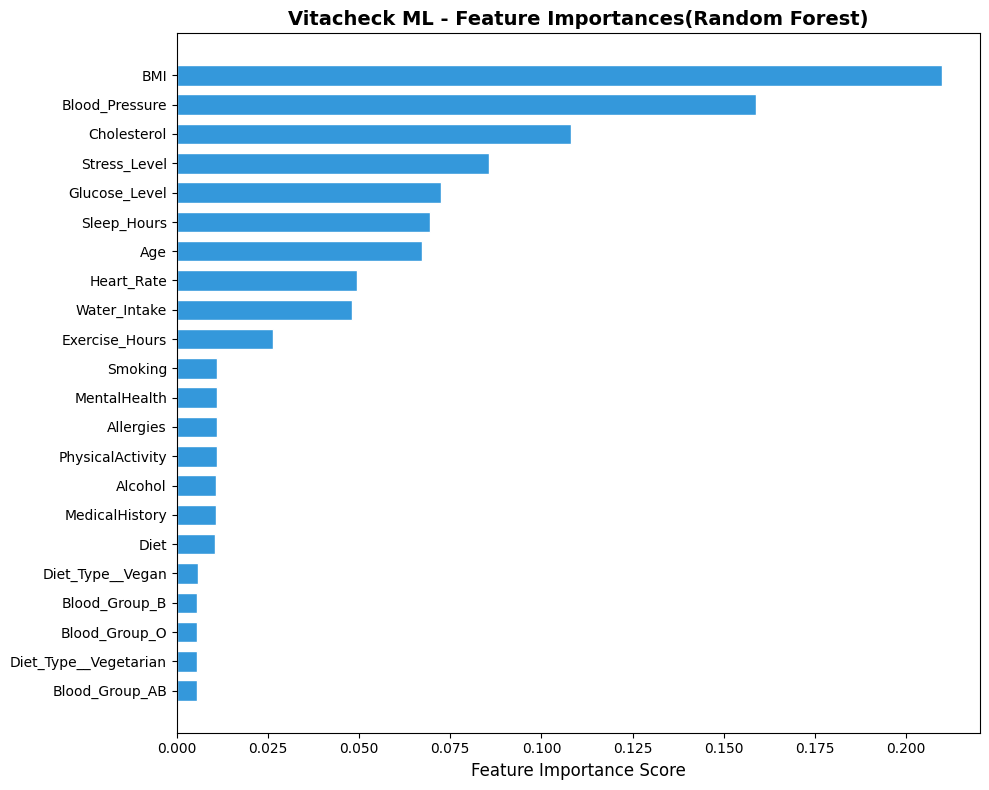

Feature importance plot saved to ../notebooks/feature_importances.png


In [24]:
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color="#3498db",
    edgecolor="white",
    height=0.7
)

for i, (feat, imp) in enumerate(zip(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)):
    plt.Text(
        imp + 0.001, i, f"{imp:.3f}", va="center", fontsize=9
    )

plt.xlabel("Feature Importance Score", fontsize=12)
plt.title("Vitacheck ML - Feature Importances(Random Forest)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/feature_importances.png", dpi=150)
plt.show()
print("Feature importance plot saved to ../notebooks/feature_importances.png")

In [25]:
importance_df.to_csv("../model/feature_importance.csv", index=False)
print("Feature importance saved to model/feature_importance.csv ✅")

Feature importance saved to model/feature_importance.csv ✅


##  Find the Best Threshold

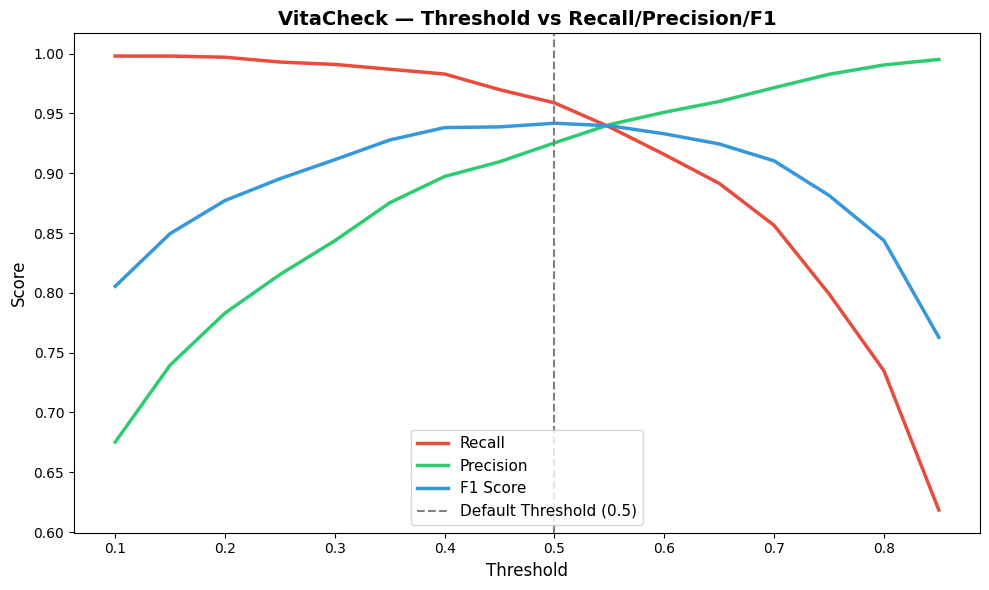

In [26]:
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

y_proba_rf = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

recalls = []
precisions = []
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_rf >= thresh).astype(int)

    recalls.append(recall_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))


plt.figure(figsize=(10, 6))

plt.plot(thresholds, recalls, label="Recall", color="#e74c3c", linewidth=2.5)
plt.plot(thresholds, precisions, label="Precision", color="#2ecc71", linewidth=2.5)
plt.plot(thresholds, f1_scores,  label="F1 Score",  
         color="#3498db", linewidth=2.5)

plt.axvline(x=0.5, color="gray", linestyle="--", label="Default Threshold (0.5)")
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("VitaCheck — Threshold vs Recall/Precision/F1", 
          fontsize=14, fontweight="bold")

plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig("../notebooks/threshold_tuning.png", dpi=150)
plt.show()


## Pick the Best Threshold

In [27]:
min_precision = 0.80

# ── Find threshold that maximises recall ───────────────
# while keeping precision above a minimum acceptable level
# We don't want precision to drop below 0.80
# because flagging every healthy person as sick is also bad

min_precision = 0.80

best_threshold = 0.5   # start with default
best_recall    = 0.0

print(f"{'Threshold':>10} {'Recall':>10} {'Precision':>10} {'F1':>10}")
print("-" * 45)

for thresh, rec, prec, f1 in zip(thresholds, recalls, precisions, f1_scores):
    print(f"{thresh:>10.2f} {rec:>10.4f} {prec:>10.4f} {f1:>10.4f}")
    
    # Update best if recall improved AND precision stays acceptable
    if rec > best_recall and prec >= min_precision:
        best_recall    = rec
        best_threshold = thresh

print(f"\n{'='*45}")
print(f"  Best Threshold : {best_threshold:.2f}")
print(f"  Best Recall    : {best_recall:.4f} ({best_recall*100:.2f}%)")
print(f"{'='*45}")

 Threshold     Recall  Precision         F1
---------------------------------------------
      0.10     0.9980     0.6753     0.8055
      0.15     0.9980     0.7396     0.8496
      0.20     0.9970     0.7831     0.8772
      0.25     0.9930     0.8153     0.8954
      0.30     0.9910     0.8436     0.9114
      0.35     0.9869     0.8753     0.9278
      0.40     0.9829     0.8973     0.9382
      0.45     0.9699     0.9096     0.9388
      0.50     0.9588     0.9254     0.9418
      0.55     0.9388     0.9406     0.9397
      0.60     0.9157     0.9510     0.9330
      0.65     0.8916     0.9600     0.9245
      0.70     0.8564     0.9715     0.9104
      0.75     0.7992     0.9827     0.8815
      0.80     0.7349     0.9905     0.8438
      0.85     0.6185     0.9952     0.7628

  Best Threshold : 0.25
  Best Recall    : 0.9930 (99.30%)


##  Apply Best Threshold + Final Evaluation

VitaCheck — Final Model Performance (Tuned Threshold)
Threshold used : 0.25 (default was 0.50)
Recall         : 99.30%
Precision      : 81.53%
F1 Score       : 89.54%
Accuracy       : 87.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.86       914
           1       0.82      0.99      0.90       996

    accuracy                           0.88      1910
   macro avg       0.90      0.87      0.88      1910
weighted avg       0.90      0.88      0.88      1910



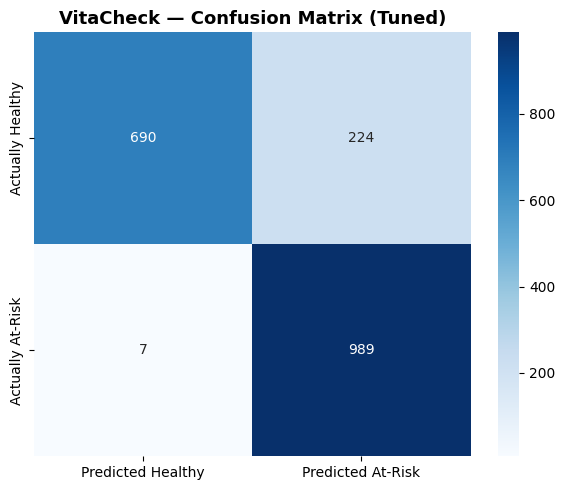


Threshold saved to model/threshold.json ✅


In [28]:
# ── Apply the best threshold ───────────────────────────
y_pred_tuned = (y_proba_rf >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("VitaCheck — Final Model Performance (Tuned Threshold)")
print("=" * 55)
print(f"Threshold used : {best_threshold:.2f} (default was 0.50)")
print(f"Recall         : {recall_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"Precision      : {precision_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"F1 Score       : {f1_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"Accuracy       : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# ── Confusion Matrix ───────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tuned)
# Confusion matrix layout:
# [[TN  FP]    TN = correctly said healthy
#  [FN  TP]]   FP = wrongly said at-risk (healthy person flagged)
#              FN = wrongly said healthy (DANGEROUS — missed sick person)
#              TP = correctly said at-risk

plt.figure(figsize=(6, 5))
import seaborn as sns
sns.heatmap(
    cm, 
    annot=True,      # show numbers inside cells
    fmt="d",         # format as integers
    cmap="Blues",
    xticklabels=["Predicted Healthy", "Predicted At-Risk"],
    yticklabels=["Actually Healthy",  "Actually At-Risk"]
)
plt.title("VitaCheck — Confusion Matrix (Tuned)", 
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix.png", dpi=150)
plt.show()

# ── Save the best threshold ────────────────────────────
# We need this in the Streamlit app
# so predictions use the same tuned threshold
import json
with open("../model/threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)
print(f"\nThreshold saved to model/threshold.json ✅")